In [1]:
import pandas as pd

df = pd.read_csv("data/processed/videos_clustered.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (500, 41)

Columns:
['ID', 'Category', 'Channel', 'Title', 'URL', 'Duration', 'Views', 'Explanation_Type', 'Visuals', 'Examples', 'Analogies', 'Real_Life', 'Quality', 'Creator_Takeaways', 'duration_seconds', 'views_numeric', 'combined_text', 'has_analogy', 'has_example', 'has_visual', 'has_application', 'has_math', 'has_code', 'text_length', 'word_count', 'log_views', 'example_length', 'analogy_length', 'visual_length', 'application_length', 'takeaway_length', 'example_suppor', 'analogy_support', 'visual_support', 'practical_support', 'takeaway_richness', 'explanation_description_richness', 'content_coverage', 'technical_terminology_density', 'technical_depth', 'cluster']


In [2]:

analysis_columns = [
    "ID",
    "Title",
    "Category",
    "Channel",
    "Duration",
    "Views",
    "cluster",
    "explanation_description_richness",
    "content_coverage",
    "technical_depth"
]

analysis_df = df[analysis_columns].copy()

analysis_df.head()

,ID,Title,Category,Channel,Duration,Views,cluster,explanation_description_richness,content_coverage,technical_depth
0,VID-001,But what is a neural network? | Deep learning ...,Machine Learning (ML),3Blue1Brown,18:40,24.2M+,7,0.545986,0.833333,0.307692
1,VID-002,"Gradient descent, how neural networks learn | ...",Machine Learning (ML),3Blue1Brown,20:33,9.5M+,7,0.315764,0.833333,0.538462
2,VID-003,A Gentle Introduction to Machine Learning,Machine Learning (ML),StatQuest with Josh Starmer,12:45,1.6M+,8,0.301675,0.666667,0.076923
3,VID-004,Machine Learning Fundamentals: Bias and Variance,Machine Learning (ML),StatQuest with Josh Starmer,6:36,1.7M+,8,0.322419,0.666667,0.000000
4,VID-005,Machine Learning Fundamentals: Cross Validation,Machine Learning (ML),StatQuest with Josh Starmer,6:05,1.5M+,8,0.219142,0.666667,0.153846


In [3]:

analysis_df[
    [
        "explanation_description_richness",
        "content_coverage",
        "technical_depth"
    ]
].describe()

,explanation_description_richness,content_coverage,technical_depth
count,500.000000,500.000000,500.000000
mean,0.386536,0.774000,0.154154
std,0.110472,0.105153,0.148272
min,0.140857,0.666667,0.000000
25%,0.302963,0.666667,0.076923
50%,0.377720,0.833333,0.115385
75%,0.462722,0.833333,0.230769
max,0.763334,1.000000,1.000000


In [4]:
correlation = analysis_df[
    [
        "explanation_description_richness",
        "content_coverage",
        "technical_depth"
    ]
].corr()

correlation

,explanation_description_richness,content_coverage,technical_depth
explanation_description_richness,1.000000,-0.040875,0.060875
content_coverage,-0.040875,1.000000,0.360408
technical_depth,0.060875,0.360408,1.000000


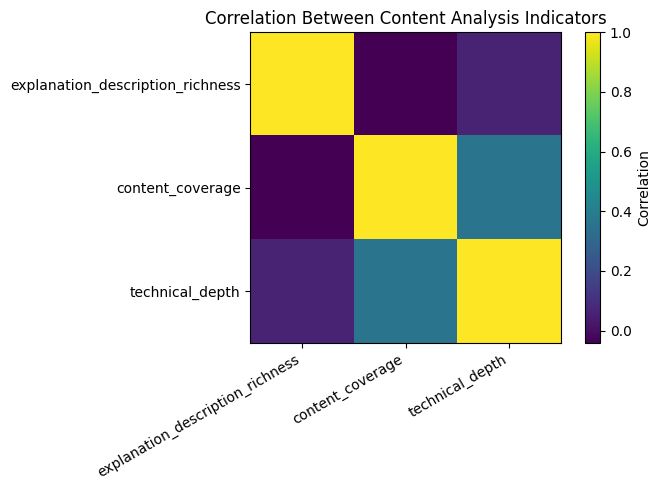

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.imshow(correlation, interpolation="nearest")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=30,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar(label="Correlation")

plt.title("Correlation Between Content Analysis Indicators")

plt.tight_layout()
plt.show()

In [7]:
cluster_analysis = (
    analysis_df
    .groupby("cluster")[
        [
            "explanation_description_richness",
            "content_coverage",
            "technical_depth"
        ]
    ]
    .mean()
    .sort_index()
)

cluster_analysis

,explanation_description_richness,content_coverage,technical_depth
cluster,,,
0,0.350241,0.816327,0.124019
1,0.389376,0.742857,0.160440
2,0.356009,0.789062,0.139423
3,0.362586,0.794686,0.207358
4,0.416826,0.786325,0.061144
5,0.378290,0.750000,0.192308
6,0.425917,0.738994,0.132075
7,0.421625,0.770833,0.225427
8,0.374654,0.765152,0.103147


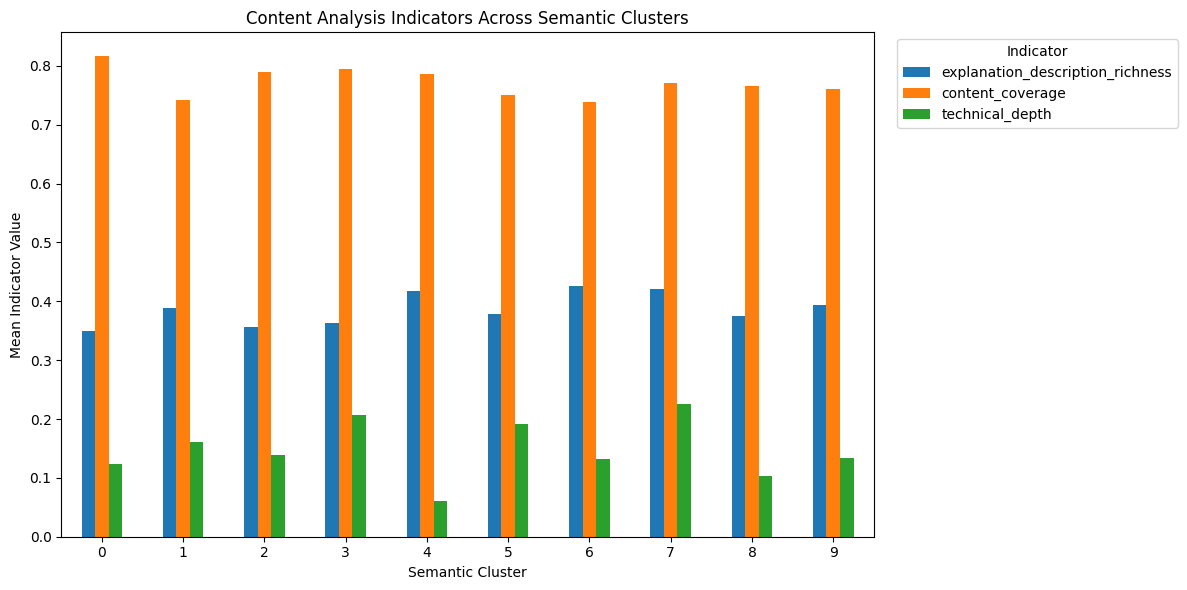

In [8]:
cluster_analysis.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Semantic Cluster")
plt.ylabel("Mean Indicator Value")
plt.title("Content Analysis Indicators Across Semantic Clusters")

plt.xticks(rotation=0)
plt.legend(
    title="Indicator",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [9]:
analysis_df["views_numeric"] = df["views_numeric"]

print(analysis_df["views_numeric"].dtype)
print(analysis_df["views_numeric"].head())

float64
0    24200000.0
1     9500000.0
2     1600000.0
3     1700000.0
4     1500000.0
Name: views_numeric, dtype: float64


In [10]:
views_correlation = analysis_df[
    [
        "views_numeric",
        "explanation_description_richness",
        "content_coverage",
        "technical_depth"
    ]
].corr()

views_correlation

,views_numeric,explanation_description_richness,content_coverage,technical_depth
views_numeric,1.000000,0.054486,0.064177,-0.002742
explanation_description_richness,0.054486,1.000000,-0.040875,0.060875
content_coverage,0.064177,-0.040875,1.000000,0.360408
technical_depth,-0.002742,0.060875,0.360408,1.000000


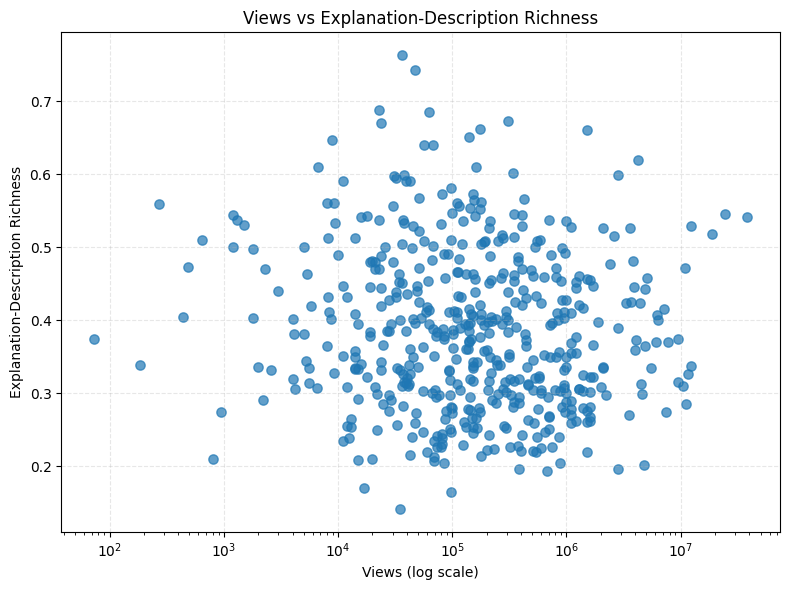

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    analysis_df["views_numeric"],
    analysis_df["explanation_description_richness"],
    alpha=0.7,
    s=45
)

plt.xscale("log")

plt.xlabel("Views (log scale)")
plt.ylabel("Explanation-Description Richness")
plt.title("Views vs Explanation-Description Richness")

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [13]:
final_analysis = analysis_df[
    [
        "ID",
        "Title",
        "Category",
        "Channel",
        "Duration",
        "Views",
        "cluster",
        "explanation_description_richness",
        "content_coverage",
        "technical_depth"
    ]
].copy()

final_analysis.head()

,ID,Title,Category,Channel,Duration,Views,cluster,explanation_description_richness,content_coverage,technical_depth
0,VID-001,But what is a neural network? | Deep learning ...,Machine Learning (ML),3Blue1Brown,18:40,24.2M+,7,0.545986,0.833333,0.307692
1,VID-002,"Gradient descent, how neural networks learn | ...",Machine Learning (ML),3Blue1Brown,20:33,9.5M+,7,0.315764,0.833333,0.538462
2,VID-003,A Gentle Introduction to Machine Learning,Machine Learning (ML),StatQuest with Josh Starmer,12:45,1.6M+,8,0.301675,0.666667,0.076923
3,VID-004,Machine Learning Fundamentals: Bias and Variance,Machine Learning (ML),StatQuest with Josh Starmer,6:36,1.7M+,8,0.322419,0.666667,0.000000
4,VID-005,Machine Learning Fundamentals: Cross Validation,Machine Learning (ML),StatQuest with Josh Starmer,6:05,1.5M+,8,0.219142,0.666667,0.153846


In [14]:
output_path = "data/processed/video_content_analysis.csv"

final_analysis.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)
print("Shape:", final_analysis.shape)

Saved: data/processed/video_content_analysis.csv
Shape: (500, 10)


In [15]:
check_df = pd.read_csv(output_path)

print("Reloaded shape:", check_df.shape)
check_df.head()

Reloaded shape: (500, 10)


,ID,Title,Category,Channel,Duration,Views,cluster,explanation_description_richness,content_coverage,technical_depth
0,VID-001,But what is a neural network? | Deep learning ...,Machine Learning (ML),3Blue1Brown,18:40,24.2M+,7,0.545986,0.833333,0.307692
1,VID-002,"Gradient descent, how neural networks learn | ...",Machine Learning (ML),3Blue1Brown,20:33,9.5M+,7,0.315764,0.833333,0.538462
2,VID-003,A Gentle Introduction to Machine Learning,Machine Learning (ML),StatQuest with Josh Starmer,12:45,1.6M+,8,0.301675,0.666667,0.076923
3,VID-004,Machine Learning Fundamentals: Bias and Variance,Machine Learning (ML),StatQuest with Josh Starmer,6:36,1.7M+,8,0.322419,0.666667,0.000000
4,VID-005,Machine Learning Fundamentals: Cross Validation,Machine Learning (ML),StatQuest with Josh Starmer,6:05,1.5M+,8,0.219142,0.666667,0.153846


In [16]:
top_richness = final_analysis.sort_values(
    "explanation_description_richness",
    ascending=False
)[
    [
        "ID",
        "Title",
        "Category",
        "explanation_description_richness"
    ]
].head(10)

top_richness

,ID,Title,Category,explanation_description_richness
480,VID-481,U-Net clearly explained | Image Segmentation w...,Computer Vision & Multimodal AI,0.763334
481,VID-482,What is end-to-end deep learning? (C3W2L09),Academic Lectures & Foundational Courses,0.743386
378,VID-379,Advanced RAG 05 - HyDE - Hypothetical Document...,Advanced Retrieval & Search,0.687504
377,VID-378,Advanced RAG: How Corrective RAG (CRAG) Solves...,Advanced Retrieval & Search,0.685850
465,VID-466,C5W3L07 Attention Model Intuition,Academic Lectures & Foundational Courses,0.673390
482,VID-483,Whether to Use End-To-End Deep Learning (C3W2L10),Academic Lectures & Foundational Courses,0.669985
374,VID-375,[GRPO Explained] DeepSeekMath: Pushing the Lim...,LLM Systems & Inference Optimization,0.661501
405,VID-406,"Geoffrey Hinton: AI, Consciousness, Immortalit...","AI History, Big Tech & Pioneer Dialogues",0.661185
466,VID-467,C4W4L04 Triplet loss,Academic Lectures & Foundational Courses,0.650385
401,VID-402,SAC | Soft Actor Critic (SAC) architecture | S...,Reinforcement Learning & Game Theory,0.646857


In [17]:
# Top 10 videos by explanation-description richness

top_richness = final_analysis.sort_values(
    "explanation_description_richness",
    ascending=False
)[
    [
        "ID",
        "Title",
        "Category",
        "explanation_description_richness"
    ]
].head(10)

top_richness

,ID,Title,Category,explanation_description_richness
480,VID-481,U-Net clearly explained | Image Segmentation w...,Computer Vision & Multimodal AI,0.763334
481,VID-482,What is end-to-end deep learning? (C3W2L09),Academic Lectures & Foundational Courses,0.743386
378,VID-379,Advanced RAG 05 - HyDE - Hypothetical Document...,Advanced Retrieval & Search,0.687504
377,VID-378,Advanced RAG: How Corrective RAG (CRAG) Solves...,Advanced Retrieval & Search,0.685850
465,VID-466,C5W3L07 Attention Model Intuition,Academic Lectures & Foundational Courses,0.673390
482,VID-483,Whether to Use End-To-End Deep Learning (C3W2L10),Academic Lectures & Foundational Courses,0.669985
374,VID-375,[GRPO Explained] DeepSeekMath: Pushing the Lim...,LLM Systems & Inference Optimization,0.661501
405,VID-406,"Geoffrey Hinton: AI, Consciousness, Immortalit...","AI History, Big Tech & Pioneer Dialogues",0.661185
466,VID-467,C4W4L04 Triplet loss,Academic Lectures & Foundational Courses,0.650385
401,VID-402,SAC | Soft Actor Critic (SAC) architecture | S...,Reinforcement Learning & Game Theory,0.646857


In [18]:
# Top 10 videos by technical depth

top_technical = final_analysis.sort_values(
    "technical_depth",
    ascending=False
)[
    [
        "ID",
        "Title",
        "Category",
        "technical_depth"
    ]
].head(10)

top_technical

,ID,Title,Category,technical_depth
347,VID-348,VQ-VAEs: Neural Discrete Representation Learni...,Generative AI & Diffusion Models,1.000000
158,VID-159,Vision Transformer Quick Guide - Theory and Co...,Advanced Neural Architectures,0.923077
124,VID-125,Residual Networks and Skip Connections (DL 15),Advanced Neural Architectures,0.692308
385,VID-386,DETR: End-to-End Object Detection with Transfo...,Computer Vision & Multimodal AI,0.692308
188,VID-189,LoRA: Low-Rank Adaptation of Large Language Mo...,LLM Systems & Inference Optimization,0.615385
415,VID-416,Sentence Transformers - EXPLAINED!,Natural Language Processing (NLP),0.615385
484,VID-485,"DALL·E 2 Explained - model architecture, resul...",Computer Vision & Multimodal AI,0.615385
480,VID-481,U-Net clearly explained | Image Segmentation w...,Computer Vision & Multimodal AI,0.615385
238,VID-239,The spelled-out intro to neural networks and b...,LLM Architecture & Open Source Implementations,0.538462
262,VID-263,Backpropagation calculus | Deep Learning Chapt...,Machine Learning (ML),0.538462


In [19]:
# Top 10 videos by content coverage

top_coverage = final_analysis.sort_values(
    "content_coverage",
    ascending=False
)[
    [
        "ID",
        "Title",
        "Category",
        "content_coverage"
    ]
].head(10)

top_coverage

,ID,Title,Category,content_coverage
478,VID-479,Gradient Checking Implementation Notes (C2W1L14),Academic Lectures & Foundational Courses,1.0
20,VID-021,Neural Network Simply Explained | Deep Learnin...,Machine Learning (ML),1.0
262,VID-263,Backpropagation calculus | Deep Learning Chapt...,Machine Learning (ML),1.0
263,VID-264,What's a Tensor?,Machine Learning (ML),1.0
296,VID-297,Building makemore Part 2: MLP,LLM Architecture & Open Source Implementations,1.0
298,VID-299,Building makemore Part 4: Becoming a Backprop ...,LLM Architecture & Open Source Implementations,1.0
322,VID-323,Intuitively Understanding the Cross Entropy Loss,Mathematics for Machine Learning,1.0
237,VID-238,"Let's build GPT: from scratch, in code, spelle...",LLM Architecture & Open Source Implementations,1.0
241,VID-242,Rotary Positional Embeddings: Combining Absolu...,LLM Architecture & Open Source Implementations,1.0
314,VID-315,Singular Value Decomposition (SVD): Matrix App...,Mathematics for Machine Learning,1.0


In [20]:
final_analysis["richness_percentile"] = (
    final_analysis["explanation_description_richness"]
    .rank(pct=True)
)

final_analysis["coverage_percentile"] = (
    final_analysis["content_coverage"]
    .rank(pct=True)
)

final_analysis["technical_percentile"] = (
    final_analysis["technical_depth"]
    .rank(pct=True)
)

final_analysis.head()

,ID,Title,Category,Channel,Duration,Views,cluster,explanation_description_richness,content_coverage,technical_depth,richness_percentile,coverage_percentile,technical_percentile
0,VID-001,But what is a neural network? | Deep learning ...,Machine Learning (ML),3Blue1Brown,18:40,24.2M+,7,0.545986,0.833333,0.307692,0.922,0.679,0.859
1,VID-002,"Gradient descent, how neural networks learn | ...",Machine Learning (ML),3Blue1Brown,20:33,9.5M+,7,0.315764,0.833333,0.538462,0.308,0.679,0.976
2,VID-003,A Gentle Introduction to Machine Learning,Machine Learning (ML),StatQuest with Josh Starmer,12:45,1.6M+,8,0.301675,0.666667,0.076923,0.244,0.221,0.357
3,VID-004,Machine Learning Fundamentals: Bias and Variance,Machine Learning (ML),StatQuest with Josh Starmer,6:36,1.7M+,8,0.322419,0.666667,0.000000,0.336,0.221,0.107
4,VID-005,Machine Learning Fundamentals: Cross Validation,Machine Learning (ML),StatQuest with Josh Starmer,6:05,1.5M+,8,0.219142,0.666667,0.153846,0.036,0.221,0.599


In [21]:
final_analysis["richness_percentile"] *= 100
final_analysis["coverage_percentile"] *= 100
final_analysis["technical_percentile"] *= 100

final_analysis.head()

,ID,Title,Category,Channel,Duration,Views,cluster,explanation_description_richness,content_coverage,technical_depth,richness_percentile,coverage_percentile,technical_percentile
0,VID-001,But what is a neural network? | Deep learning ...,Machine Learning (ML),3Blue1Brown,18:40,24.2M+,7,0.545986,0.833333,0.307692,92.2,67.9,85.9
1,VID-002,"Gradient descent, how neural networks learn | ...",Machine Learning (ML),3Blue1Brown,20:33,9.5M+,7,0.315764,0.833333,0.538462,30.8,67.9,97.6
2,VID-003,A Gentle Introduction to Machine Learning,Machine Learning (ML),StatQuest with Josh Starmer,12:45,1.6M+,8,0.301675,0.666667,0.076923,24.4,22.1,35.7
3,VID-004,Machine Learning Fundamentals: Bias and Variance,Machine Learning (ML),StatQuest with Josh Starmer,6:36,1.7M+,8,0.322419,0.666667,0.000000,33.6,22.1,10.7
4,VID-005,Machine Learning Fundamentals: Cross Validation,Machine Learning (ML),StatQuest with Josh Starmer,6:05,1.5M+,8,0.219142,0.666667,0.153846,3.6,22.1,59.9


In [22]:
output_path = "data/processed/video_content_analysis.csv"

final_analysis.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)
print("Shape:", final_analysis.shape)

Saved: data/processed/video_content_analysis.csv
Shape: (500, 13)


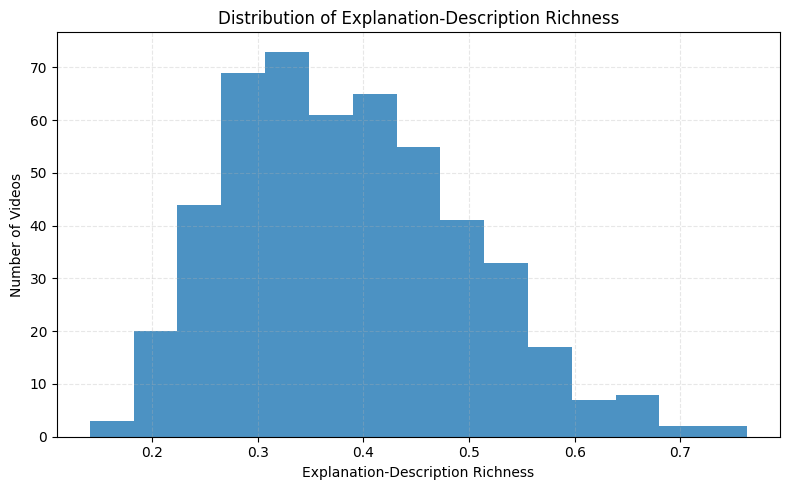

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    final_analysis["explanation_description_richness"],
    bins=15,
    alpha=0.8
)

plt.xlabel("Explanation-Description Richness")
plt.ylabel("Number of Videos")
plt.title("Distribution of Explanation-Description Richness")

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

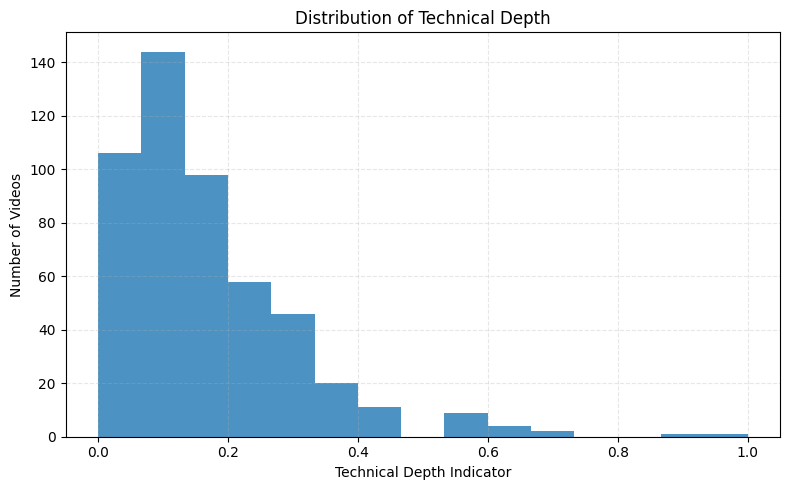

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(
    final_analysis["technical_depth"],
    bins=15,
    alpha=0.8
)

plt.xlabel("Technical Depth Indicator")
plt.ylabel("Number of Videos")
plt.title("Distribution of Technical Depth")

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

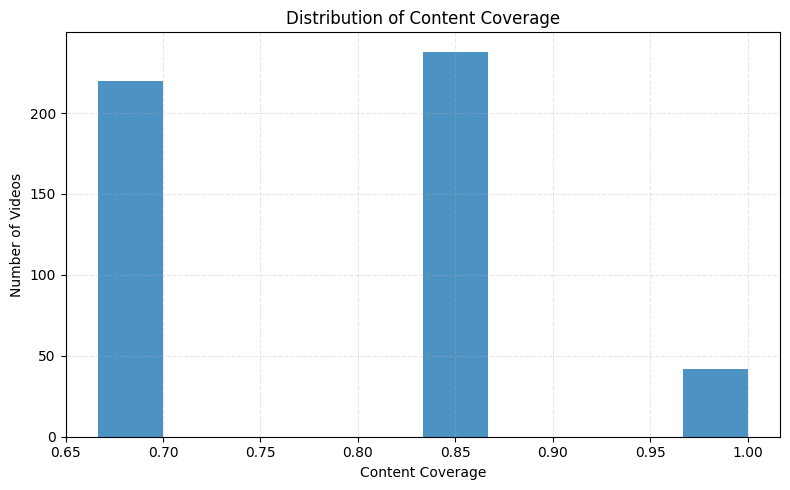

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(
    final_analysis["content_coverage"],
    bins=10,
    alpha=0.8
)

plt.xlabel("Content Coverage")
plt.ylabel("Number of Videos")
plt.title("Distribution of Content Coverage")

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

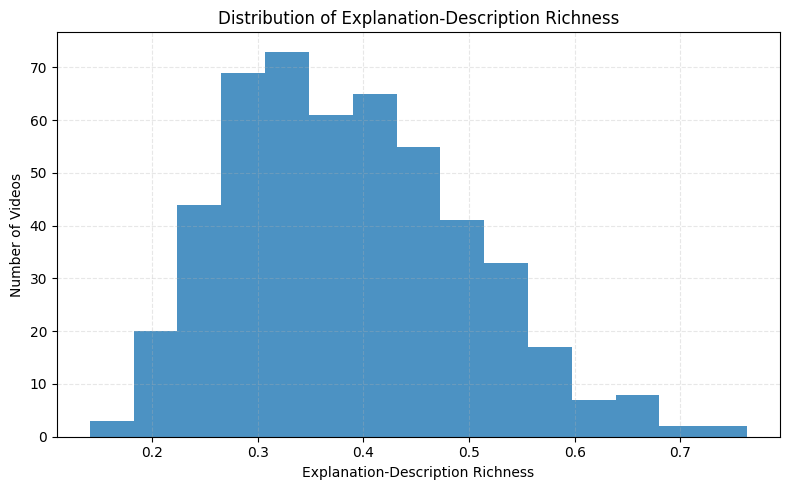

In [26]:
# Explanation richness
plt.figure(figsize=(8, 5))
plt.hist(final_analysis["explanation_description_richness"], bins=15, alpha=0.8)
plt.xlabel("Explanation-Description Richness")
plt.ylabel("Number of Videos")
plt.title("Distribution of Explanation-Description Richness")
plt.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("results/figures/explanation_richness_distribution.png", dpi=300)
plt.show()

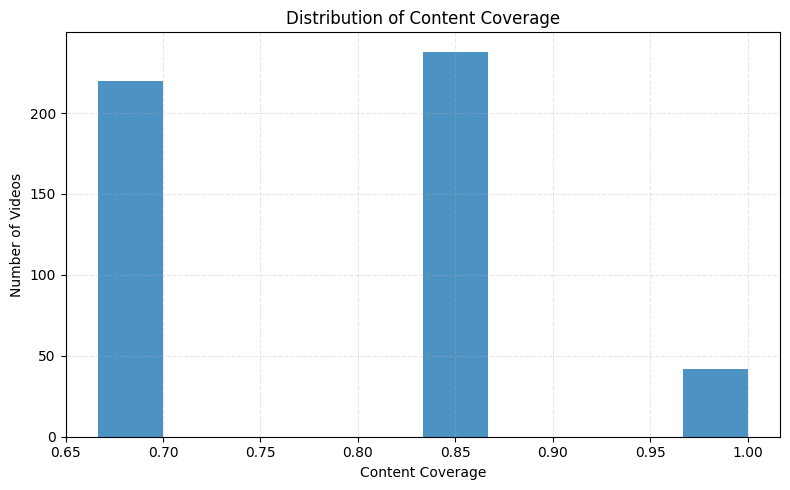

In [27]:
# Content coverage
plt.figure(figsize=(8, 5))
plt.hist(final_analysis["content_coverage"], bins=10, alpha=0.8)
plt.xlabel("Content Coverage")
plt.ylabel("Number of Videos")
plt.title("Distribution of Content Coverage")
plt.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("results/figures/content_coverage_distribution.png", dpi=300)
plt.show()